## Upload Data Files:

* Upload the data files for each branch in CSV format.
* Ensure the files are accessible and note their paths.

Update list_of_places:
* Replace the existing paths in the list_of_places variable with the paths of the uploaded CSV files.
* Example:

```
# list_of_places = [
    "/content/Bayridge.csv",
    "/content/Dekalb.csv",
    "/content/Dumbo.csv",
    "/content/Myrtle.csv",
    "/content/Vanderbiltt.csv"]
```
* Modify the start and end dates for the sales period.
* Example:

```
# Start and end of sales parameters
first_day = '10-15-2023'
last_day = '10-28-2023'
```

* Execute the process_sheets function with the updated data and date range.
* Example:

```
# result_dataframe = process_sheets(list_of_places, first_day, last_day)
```
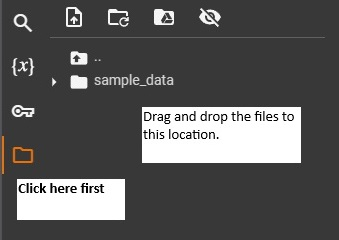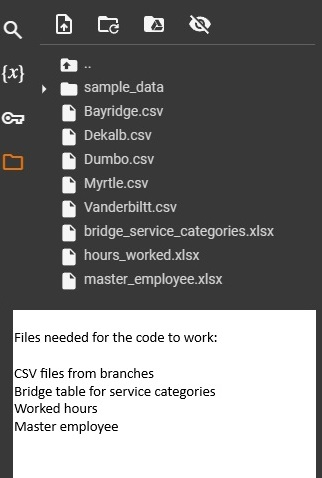

In [ ]:
# Config and engine imports (run first)
import os
import pandas as pd
from config import CONFIG
from payroll_engine import (
    add_service_category,
    add_id,
    hour_worked,
    validate_inputs,
    apply_double_booking_allocation,
    apply_double_booking_flag_to_payroll,
    calculation,
    build_exception_report,
    build_location_summary,
    write_run_log,
)
from integrations import get_pos_adapter, get_payroll_adapter, get_payroll_export_path
# Optional: override paths for Colab (e.g. /content/...)
# CONFIG["list_of_places"] = ["/content/Bay Ridge.csv", ...]
# CONFIG["path_dates"] = "/content/Tabela_Datas.xlsx"
# CONFIG["path_database"] = "/content/Database.xlsx"
# ... etc.
os.makedirs(os.path.dirname(CONFIG["path_database"]) or ".", exist_ok=True)

In [ ]:
# Run full pipeline (ingestion -> service category -> add id -> hours -> validate -> commission -> exception report -> ADP export -> run log)
import os
from datetime import datetime
import pandas as pd
from config import CONFIG
from payroll_engine import (
    add_service_category, add_id, hour_worked,
    validate_inputs, apply_double_booking_allocation, apply_double_booking_flag_to_payroll,
    calculation, build_exception_report,
    build_location_summary, write_run_log,
)
from integrations import get_pos_adapter, get_payroll_adapter, get_payroll_export_path

# 1) Dates: load from file or use a default range
if os.path.isfile(CONFIG["path_dates"]):
    df_dates = pd.read_excel(CONFIG["path_dates"])
else:
    df_dates = pd.DataFrame([[(datetime(2024, 11, 10)), (datetime(2024, 11, 16))]], columns=["first_day", "last_day"])

# 2) Ingest branch CSVs (skip missing files)
places = [p for p in CONFIG["list_of_places"] if os.path.isfile(p)]
if not places:
    raise FileNotFoundError("No branch CSV files found. Update CONFIG['list_of_places'] with paths to your branch CSVs.")
database_01 = get_pos_adapter(CONFIG).ingest(places, df_dates, CONFIG)
if database_01.empty:
    raise ValueError("No data after ingestion. Check CSV paths and format.")
database_01.to_excel(CONFIG["path_database"], index=False)
first_day, last_day = df_dates.iloc[0, 0], df_dates.iloc[0, -1]

# 2b) Location summary
location_summary = build_location_summary(database_01)
location_summary.to_excel(CONFIG["path_location_summary"], index=False)

# 3) Service category
database_01 = pd.read_excel(CONFIG["path_database"])
database_01, missing_services = add_service_category(database_01, CONFIG["path_bridge_service_categories"])
database_01.to_excel(CONFIG["path_database"], index=False)
if not missing_services.empty:
    missing_services.to_excel(CONFIG["path_missing_services"], index=False)

# 4) Employee ID
database_01, missing_employees = add_id(database_01, CONFIG["path_master_employee"])
# 4b) Double-booking allocation (flag_only or first_only) and audit trail
database_01, flagged_ids = apply_double_booking_allocation(
    database_01, CONFIG, first_day, last_day, CONFIG.get("path_override_audit_log")
)
database_01.to_excel(CONFIG["path_database"], index=False)
if not missing_employees.empty:
    missing_employees.to_excel(CONFIG["path_missing_employees"], index=False)

# 5) Hours worked summary
hour_worked(CONFIG["path_hours_worked"], CONFIG["path_master_employee"], CONFIG["path_hours_summ"])

# 6) Validation
validation_issues = validate_inputs(
    database_01, CONFIG["path_master_employee"], CONFIG["path_bridge_service_categories"], CONFIG["path_hours_summ"]
)
for i in validation_issues:
    print(f"[{i['severity']}] {i['message']}")

# 7) Commission calculation (service 1-5, retail 1-4; Cat 4 = $800 threshold)
final = calculation(CONFIG["path_database"], CONFIG["path_master_employee"], CONFIG["path_hours_summ"], CONFIG)
final = apply_double_booking_flag_to_payroll(final, flagged_ids)
final.to_excel(CONFIG["path_final_database"], index=False)

# 8) Exception report
exception_df = build_exception_report(
    missing_employees, missing_services, validation_issues, final, first_day, last_day
)
exception_df.to_excel(CONFIG["path_exception_report"], index=False)

# 9) Payroll export (ADP / TriNet / Paylocity per CONFIG["payroll_provider"])
path_payroll = get_payroll_export_path(CONFIG)
get_payroll_adapter(CONFIG).export(final, path_payroll, CONFIG)

# 10) Run log
write_run_log(
    CONFIG["path_run_log"],
    {k: v for k, v in CONFIG.items() if k.startswith("path_") and isinstance(v, str)},
    (first_day, last_day),
    validation_issues,
    {"database": len(database_01), "payroll": len(final), "exceptions": len(exception_df)},
)
# 11) Historical warehouse and trend report
from payroll_warehouse import save_payroll_run, build_trend_report
save_payroll_run(
    CONFIG.get("path_warehouse", "output/payroll_warehouse.db"),
    final, first_day, last_day,
    location_summary_df=location_summary,
    exception_count=len(exception_df),
)
build_trend_report(CONFIG.get("path_warehouse", "output/payroll_warehouse.db"), CONFIG.get("path_trend_report", "output/payroll_trend_report.xlsx"))
print("Done. Outputs:", CONFIG["path_final_database"], CONFIG["path_exception_report"], path_payroll, CONFIG["path_location_summary"], CONFIG.get("path_trend_report"))